In [1]:
import pandas as pd
file_path = "/kaggle/input/datasets/andrewmvd/heart-failure-clinical-data/heart_failure_clinical_records_dataset.csv"
df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (299, 13)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [2]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Number of Rows: 299
Number of Columns: 13

Column Names:
['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'DEATH_EVENT']

Data Types:
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object


In [3]:

print("===== DATASET SUMMARY =====")

print("\nNumber of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTotal Missing Values:", df.isnull().sum().sum())

===== DATASET SUMMARY =====

Number of Rows: 299
Number of Columns: 13

Data Types:
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

Missing Values:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

Total Missing

In [5]:
import numpy as np
numeric_columns = df.select_dtypes(include=np.number).columns

before_cleaning_stats = df[numeric_columns].describe().T

before_cleaning_stats = before_cleaning_stats[
    ["mean", "50%", "std", "min", "max"]
]

before_cleaning_stats.rename(
    columns={"50%": "median"},
    inplace=True
)

before_cleaning_stats

,mean,median,std,min,max
age,60.833893,60.0,11.894809,40.0,95.0
anaemia,0.431438,0.0,0.496107,0.0,1.0
creatinine_phosphokinase,581.839465,250.0,970.287881,23.0,7861.0
diabetes,0.418060,0.0,0.494067,0.0,1.0
ejection_fraction,38.083612,38.0,11.834841,14.0,80.0
high_blood_pressure,0.351171,0.0,0.478136,0.0,1.0
platelets,263358.029264,262000.0,97804.236869,25100.0,850000.0
serum_creatinine,1.393880,1.1,1.034510,0.5,9.4
serum_sodium,136.625418,137.0,4.412477,113.0,148.0
sex,0.648829,1.0,0.478136,0.0,1.0


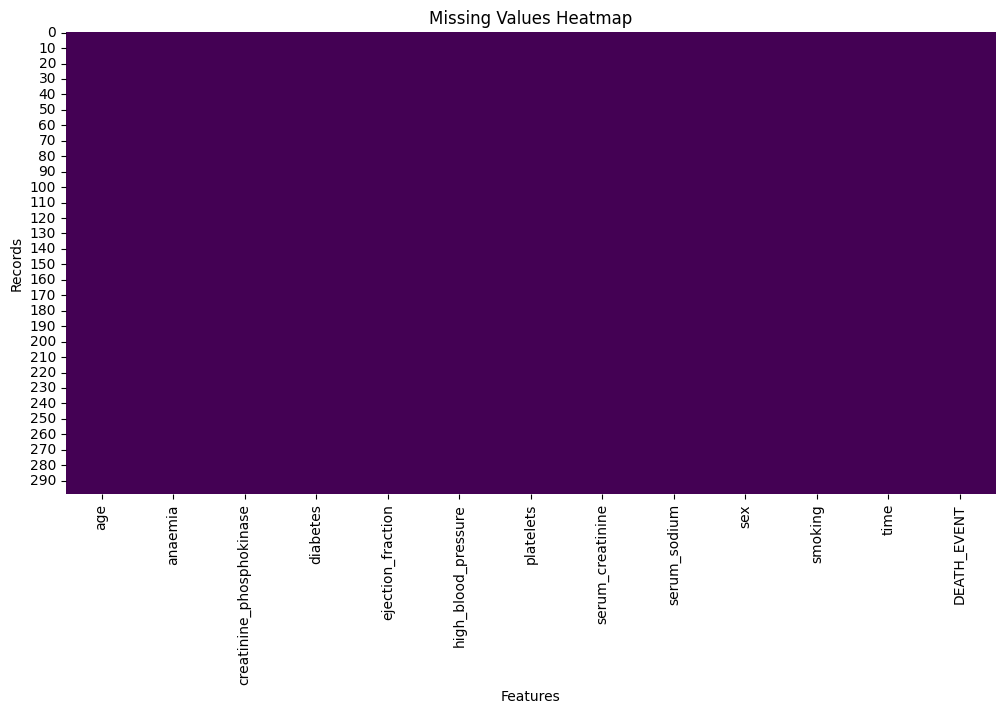

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")
plt.xlabel("Features")
plt.ylabel("Records")

plt.show()

In [8]:

for column in df.columns:
    print(f"\n{column}:")
    print("Data type:", df[column].dtype)
    print("Unique values:", df[column].unique()[:20])


age:
Data type: float64
Unique values: [75. 55. 65. 50. 90. 60. 80. 62. 45. 49. 82. 87. 70. 48. 68. 53. 95. 58.
 94. 85.]

anaemia:
Data type: int64
Unique values: [0 1]

creatinine_phosphokinase:
Data type: int64
Unique values: [ 582 7861  146  111  160   47  246  315  157  123   81  231  981  168
   80  379  149  125   52  128]

diabetes:
Data type: int64
Unique values: [0 1]

ejection_fraction:
Data type: int64
Unique values: [20 38 40 15 60 65 35 25 30 50 14 55 45 62 80 17 70]

high_blood_pressure:
Data type: int64
Unique values: [1 0]

platelets:
Data type: float64
Unique values: [265000.   263358.03 162000.   210000.   327000.   204000.   127000.
 454000.   388000.   368000.   253000.   136000.   276000.   427000.
  47000.   262000.   166000.   237000.    87000.   297000.  ]

serum_creatinine:
Data type: float64
Unique values: [1.9  1.1  1.3  2.7  2.1  1.2  1.5  9.4  4.   0.9  1.   0.8  1.6  1.83
 5.8  3.   3.5  2.3  0.6  4.4 ]

serum_sodium:
Data type: int64
Unique values: [130

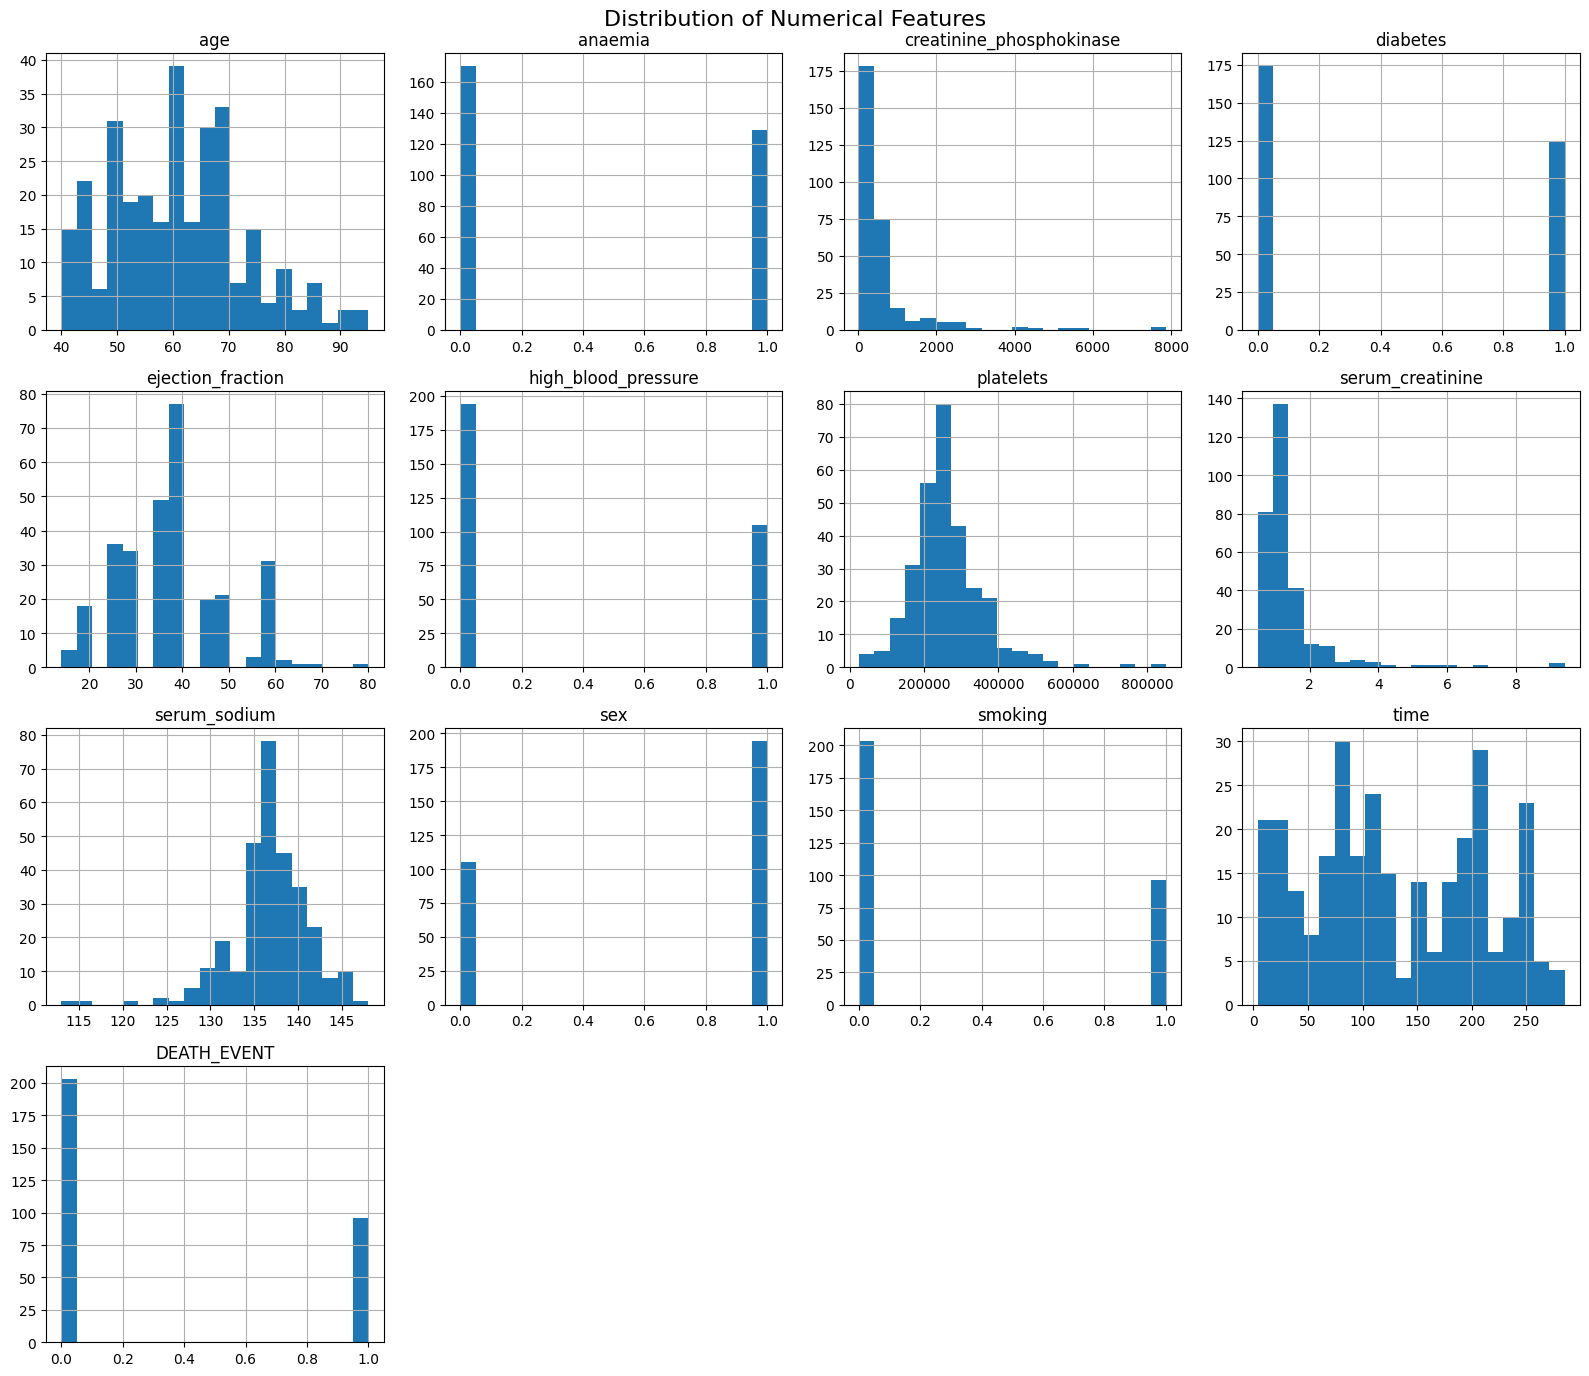

In [9]:

numerical_columns = df.select_dtypes(include=np.number).columns

df[numerical_columns].hist(
    figsize=(16, 14),
    bins=20
)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

In [11]:
print("Remaining Missing Values:")
print(df.isnull().sum())

print("\nTotal Missing Values:",
      df.isnull().sum().sum())

Remaining Missing Values:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

Total Missing Values: 0


## Removeing Outliers

In [12]:
numerical_columns = df.select_dtypes(
    include="number"
).columns

outlier_summary = {}

for column in numerical_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_summary[column] = len(outliers)

outlier_summary

{'age': 0,
 'anaemia': 0,
 'creatinine_phosphokinase': 29,
 'diabetes': 0,
 'ejection_fraction': 2,
 'high_blood_pressure': 0,
 'platelets': 21,
 'serum_creatinine': 29,
 'serum_sodium': 4,
 'sex': 0,
 'smoking': 0,
 'time': 0,
 'DEATH_EVENT': 0}

In [13]:

df_clean = df.copy()

for column in numerical_columns:

    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_clean = df_clean[
        (df_clean[column] >= lower_bound) &
        (df_clean[column] <= upper_bound)
    ]

df_clean.reset_index(drop=True, inplace=True)

print("Original Dataset Shape:", df.shape)
print("After Outlier Removal:", df_clean.shape)

Original Dataset Shape: (299, 13)
After Outlier Removal: (224, 13)


## Correct Inconsistencies

In [14]:
print("Negative Age:",
      (df_clean["age"] < 0).sum())

print("Negative Ejection Fraction:",
      (df_clean["ejection_fraction"] < 0).sum())

print("Negative Serum Creatinine:",
      (df_clean["serum_creatinine"] < 0).sum())

print("Negative Platelets:",
      (df_clean["platelets"] < 0).sum())

Negative Age: 0
Negative Ejection Fraction: 0
Negative Serum Creatinine: 0
Negative Platelets: 0


## Feature Engineering 

### Age Group Feature

In [16]:
def create_age_group(age):

    if age < 40:
        return "<40"

    elif age <= 60:
        return "40-60"

    else:
        return ">60"


df_clean["age_group"] = df_clean["age"].apply(
    create_age_group
)

df_clean[["age", "age_group"]].head(10)

,age,age_group
0,75.0,>60
1,65.0,>60
2,50.0,40-60
3,90.0,>60
4,75.0,>60
5,65.0,>60
6,62.0,>60
7,45.0,40-60
8,50.0,40-60
9,49.0,40-60


age_group
40-60    115
>60      109
Name: count, dtype: int64


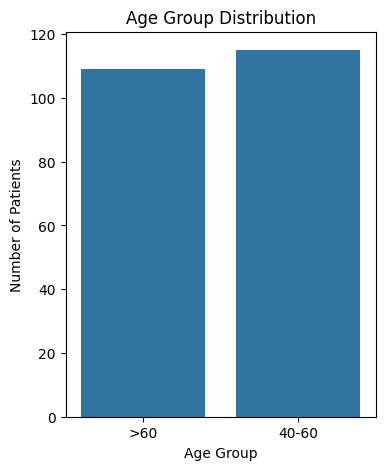

In [23]:

print(df_clean["age_group"].value_counts())

plt.figure(figsize=(4, 5))

sns.countplot(
    data=df_clean,
    x="age_group"
)

plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")

plt.show()

### Risk Score Feature

In [24]:

from sklearn.preprocessing import MinMaxScaler

df_clean["risk_score_raw"] = (
    df_clean["ejection_fraction"] *
    df_clean["serum_creatinine"]
)

risk_scaler = MinMaxScaler()

df_clean["risk_score"] = risk_scaler.fit_transform(
    df_clean[["risk_score_raw"]]
)

df_clean[
    [
        "ejection_fraction",
        "serum_creatinine",
        "risk_score"
    ]
].head(10)

,ejection_fraction,serum_creatinine,risk_score
0,20,1.9,0.310545
1,20,1.3,0.171495
2,20,1.9,0.310545
3,40,2.1,0.843569
4,15,1.2,0.078795
5,65,1.5,1.000000
6,25,0.9,0.130939
7,30,1.1,0.252607
8,38,1.1,0.354577
9,30,1.0,0.217845


## Encode Categorical Variables

In [25]:
# Task 10: Convert binary variables to categorical values

df_clean["sex"] = df_clean["sex"].map({
    0: "Female",
    1: "Male"
})

df_clean["smoking"] = df_clean["smoking"].map({
    0: "No",
    1: "Yes"
})

df_clean[
    ["sex", "smoking"]
].head()

,sex,smoking
0,Male,No
1,Male,Yes
2,Male,No
3,Male,Yes
4,Male,No


In [26]:

df_clean = pd.get_dummies(
    df_clean,
    columns=["sex", "smoking"],
    drop_first=True,
    dtype=int
)

df_clean.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,time,DEATH_EVENT,age_group,risk_score_raw,risk_score,sex_Male,smoking_Yes
0,75.0,0,582,0,20,1,265000.0,1.9,130,4,1,>60,38.0,0.310545,1,0
1,65.0,0,146,0,20,0,162000.0,1.3,129,7,1,>60,26.0,0.171495,1,1
2,50.0,1,111,0,20,0,210000.0,1.9,137,7,1,40-60,38.0,0.310545,1,0
3,90.0,1,47,0,40,1,204000.0,2.1,132,8,1,>60,84.0,0.843569,1,1
4,75.0,1,246,0,15,0,127000.0,1.2,137,10,1,>60,18.0,0.078795,1,0


In [27]:
df_clean = pd.get_dummies(
    df_clean,
    columns=["age_group"],
    drop_first=True,
    dtype=int
)

df_clean.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,time,DEATH_EVENT,risk_score_raw,risk_score,sex_Male,smoking_Yes,age_group_>60
0,75.0,0,582,0,20,1,265000.0,1.9,130,4,1,38.0,0.310545,1,0,1
1,65.0,0,146,0,20,0,162000.0,1.3,129,7,1,26.0,0.171495,1,1,1
2,50.0,1,111,0,20,0,210000.0,1.9,137,7,1,38.0,0.310545,1,0,0
3,90.0,1,47,0,40,1,204000.0,2.1,132,8,1,84.0,0.843569,1,1,1
4,75.0,1,246,0,15,0,127000.0,1.2,137,10,1,18.0,0.078795,1,0,1


## Normalize Features

In [28]:
from sklearn.preprocessing import MinMaxScaler

columns_to_scale = [
    "age",
    "anaemia",
    "creatinine_phosphokinase",
    "diabetes",
    "ejection_fraction",
    "high_blood_pressure",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "time"
]

scaler = MinMaxScaler()

df_clean[columns_to_scale] = scaler.fit_transform(
    df_clean[columns_to_scale]
)

print("Numerical features normalized successfully.")

Numerical features normalized successfully.


In [29]:

print(
    df_clean[columns_to_scale].min()
)

print(
    df_clean[columns_to_scale].max()
)

age                         0.0
anaemia                     0.0
creatinine_phosphokinase    0.0
diabetes                    0.0
ejection_fraction           0.0
high_blood_pressure         0.0
platelets                   0.0
serum_creatinine            0.0
serum_sodium                0.0
time                        0.0
dtype: float64
age                         1.0
anaemia                     1.0
creatinine_phosphokinase    1.0
diabetes                    1.0
ejection_fraction           1.0
high_blood_pressure         1.0
platelets                   1.0
serum_creatinine            1.0
serum_sodium                1.0
time                        1.0
dtype: float64


## Summary Statistics

### Before:

In [30]:
original_numeric = df.select_dtypes(
    include="number"
).columns

before_stats = pd.DataFrame({
    "Mean": df[original_numeric].mean(),
    "Median": df[original_numeric].median(),
    "Standard Deviation": df[original_numeric].std()
})

before_stats

,Mean,Median,Standard Deviation
age,60.833893,60.0,11.894809
anaemia,0.431438,0.0,0.496107
creatinine_phosphokinase,581.839465,250.0,970.287881
diabetes,0.418060,0.0,0.494067
ejection_fraction,38.083612,38.0,11.834841
high_blood_pressure,0.351171,0.0,0.478136
platelets,263358.029264,262000.0,97804.236869
serum_creatinine,1.393880,1.1,1.034510
serum_sodium,136.625418,137.0,4.412477
sex,0.648829,1.0,0.478136


### After:

In [33]:

common_numeric_columns = [
    column for column in original_numeric
    if column in df_clean.columns
]

after_stats = pd.DataFrame({
    "Mean": df_clean[common_numeric_columns].mean(),
    "Median": df_clean[common_numeric_columns].median(),
    "Standard Deviation": df_clean[common_numeric_columns].std()
})

after_stats

,Mean,Median,Standard Deviation
age,0.378355,0.363636,0.217202
anaemia,0.468750,0.000000,0.500140
creatinine_phosphokinase,0.261896,0.155290,0.238499
diabetes,0.419643,0.000000,0.494606
ejection_fraction,0.474090,0.470588,0.229624
high_blood_pressure,0.379464,0.000000,0.486340
platelets,0.438902,0.460656,0.220176
serum_creatinine,0.352381,0.333333,0.218530
serum_sodium,0.523680,0.521739,0.165510
time,0.457836,0.412811,0.272526


In [34]:

comparison = pd.DataFrame({
    "Before Mean": before_stats.loc[common_numeric_columns, "Mean"],
    "After Mean": after_stats["Mean"],

    "Before Median": before_stats.loc[common_numeric_columns, "Median"],
    "After Median": after_stats["Median"],

    "Before Std": before_stats.loc[common_numeric_columns, "Standard Deviation"],
    "After Std": after_stats["Standard Deviation"]
})

comparison

,Before Mean,After Mean,Before Median,After Median,Before Std,After Std
age,60.833893,0.378355,60.0,0.363636,11.894809,0.217202
anaemia,0.431438,0.468750,0.0,0.000000,0.496107,0.500140
creatinine_phosphokinase,581.839465,0.261896,250.0,0.155290,970.287881,0.238499
diabetes,0.418060,0.419643,0.0,0.000000,0.494067,0.494606
ejection_fraction,38.083612,0.474090,38.0,0.470588,11.834841,0.229624
high_blood_pressure,0.351171,0.379464,0.0,0.000000,0.478136,0.486340
platelets,263358.029264,0.438902,262000.0,0.460656,97804.236869,0.220176
serum_creatinine,1.393880,0.352381,1.1,0.333333,1.034510,0.218530
serum_sodium,136.625418,0.523680,137.0,0.521739,4.412477,0.165510
time,130.260870,0.457836,115.0,0.412811,77.614208,0.272526


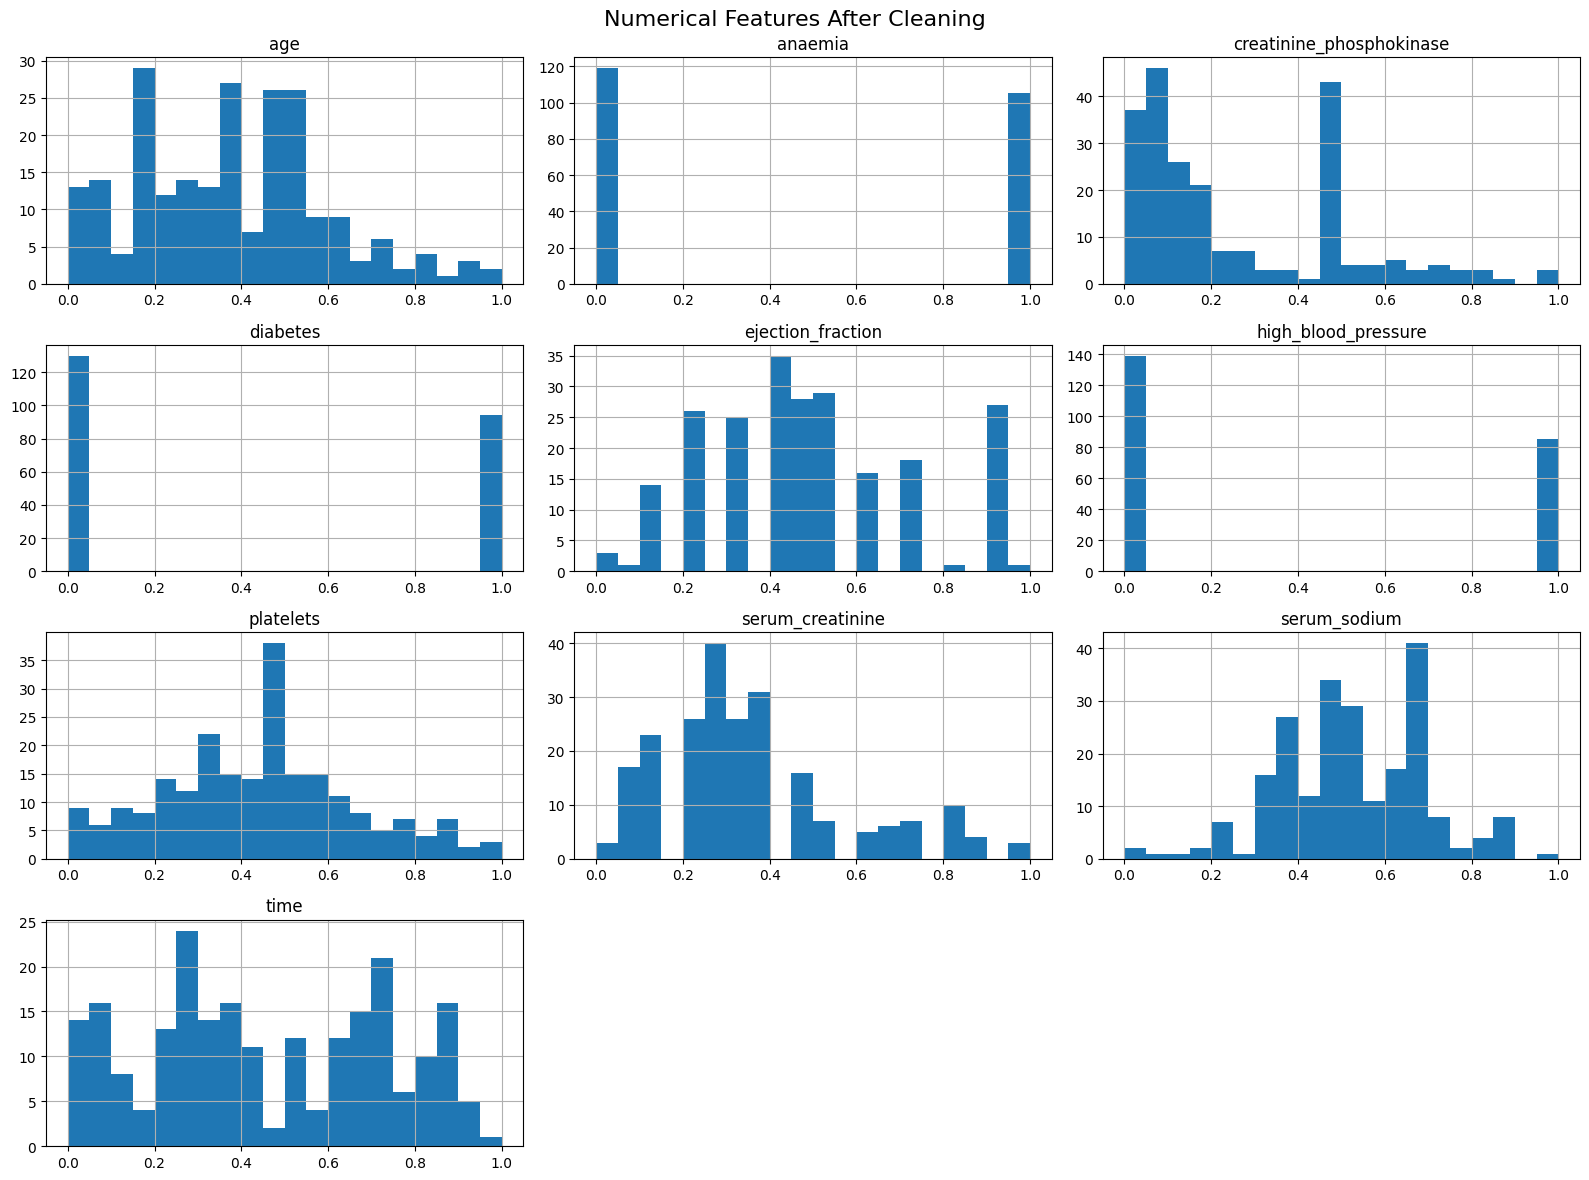

In [35]:

df_clean[columns_to_scale].hist(
    figsize=(16, 12),
    bins=20
)

plt.suptitle(
    "Numerical Features After Cleaning",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [36]:

print("Final Dataset Shape:", df_clean.shape)

df_clean.head(10)

Final Dataset Shape: (224, 16)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,time,DEATH_EVENT,risk_score_raw,risk_score,sex_Male,smoking_Yes,age_group_>60
0,0.636364,0.0,0.470990,0.0,0.117647,1.0,0.468852,0.866667,0.217391,0.000000,1,38.0,0.310545,1,0,1
1,0.454545,0.0,0.098976,0.0,0.117647,0.0,0.131148,0.466667,0.173913,0.010676,1,26.0,0.171495,1,1,1
2,0.181818,1.0,0.069113,0.0,0.117647,0.0,0.288525,0.866667,0.521739,0.010676,1,38.0,0.310545,1,0,0
3,0.909091,1.0,0.014505,0.0,0.509804,1.0,0.268852,1.000000,0.304348,0.014235,1,84.0,0.843569,1,1,1
4,0.636364,1.0,0.184300,0.0,0.019608,0.0,0.016393,0.400000,0.521739,0.021352,1,18.0,0.078795,1,0,1
5,0.454545,0.0,0.108362,0.0,1.000000,0.0,0.463469,0.600000,0.565217,0.021352,1,97.5,1.000000,0,0,1
6,0.400000,0.0,0.171502,0.0,0.215686,1.0,0.429508,0.200000,0.652174,0.021352,1,22.5,0.130939,1,1,1
7,0.090909,1.0,0.811433,0.0,0.313725,0.0,0.045902,0.333333,0.521739,0.024911,1,33.0,0.252607,1,0,0
8,0.181818,1.0,0.117747,0.0,0.470588,1.0,0.504918,0.333333,0.521739,0.024911,1,41.8,0.354577,1,0,0
9,0.163636,1.0,0.042662,0.0,0.313725,1.0,1.000000,0.266667,0.565217,0.028470,0,30.0,0.217845,0,0,0
